In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

print("Libraries loaded as expected")

Libraries loaded as expected


In [2]:
df = pd.read_csv('Planetary_data.csv', comment='#')
df.head(3)

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826


<Axes: title={'center': 'Heavy planets create single planetery solar systems'}, xlabel='system_type'>

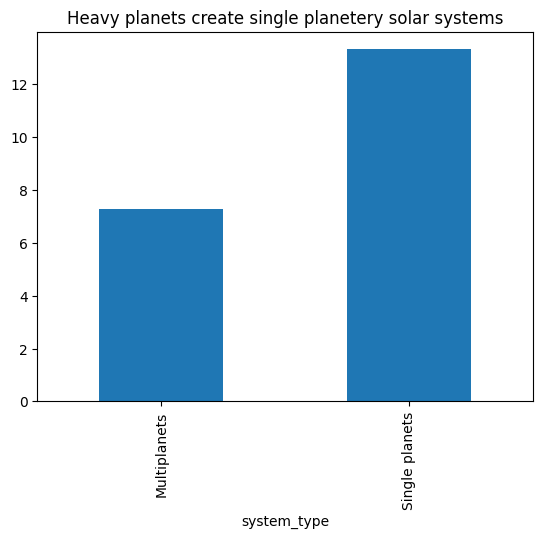

In [17]:
# Do hot jupiters create a single planetary solar system?
# If a solar system has a massive, Jupiter-like planet, its gravitational pull is so extreme that over millions of years, it either flings the smaller planets out into deep space or pulls them into the star.
# If a system is filled with smaller planets (like the 7.26 median), they can all happily coexist without destroying each other's orbits.

df['system_type'] = np.where(df['sy_pnum'] == 1, "Single planets", "Multiplanets")
subset = df.dropna(subset=['pl_bmasse'])
data = subset.groupby('system_type')['pl_bmasse'].median()
data.plot(kind='bar', title="Heavy planets create single planetery solar systems")


planet_class
Super-Earth           2754
Jovian (Gas Giant)    2039
Neptune-like           946
Earth / Sub-Earth      516
Name: count, dtype: int64


<Axes: >

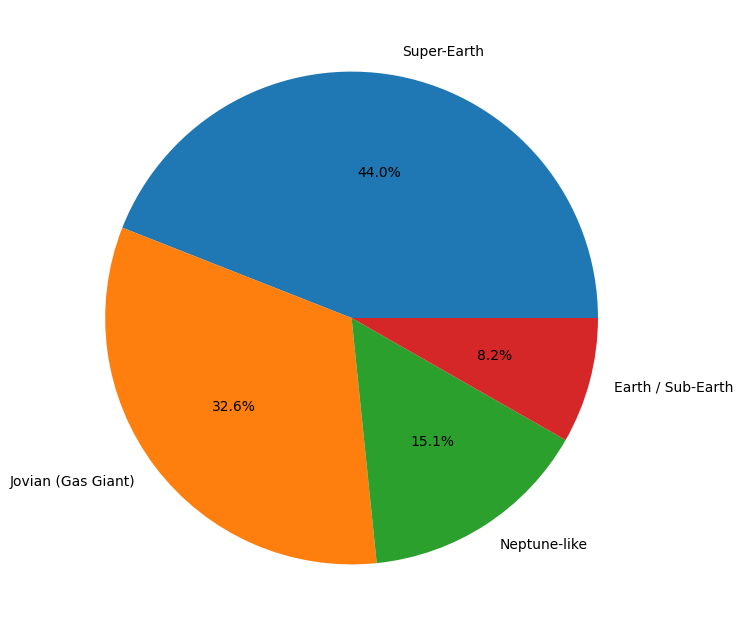

In [29]:
# Distibution of planetary weight classes

clean_mass_df = df.dropna(subset=['pl_bmasse']).copy()
bin_edges = [0, 2, 10, 50, float('inf')]
label_desc = ['Earth / Sub-Earth', 'Super-Earth', 'Neptune-like', 'Jovian (Gas Giant)']
clean_mass_df['planet_class'] = pd.cut(clean_mass_df['pl_bmasse'], bins=bin_edges, labels=label_desc)

planet_census = clean_mass_df['planet_class'].value_counts()

print(planet_census)

planet_census.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8), ylabel='')